In [1]:
import sys
import os
# Add parent directory to path to import dolphain if not installed
sys.path.append('..')

import dolphain
from dolphain import getData
from dolphain.catalog import Catalog
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/Users/mjhaas/code/dolphain/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Stitching Demo

This notebook demonstrates how to fetch acoustic data across multiple file boundaries using Dolphain's built-in catalog and time-based data access.

## 1. Load the Built-in Catalog

Dolphain now includes a built-in catalog with 1000 sample files. No need to build one - just load it!

In [2]:
# Load the built-in default catalog (no arguments needed!)
catalog = Catalog()
catalog_df = catalog.df

print(f"Loaded built-in catalog with {len(catalog_df)} files")
print(f"Time range: {catalog_df['start_time'].min()} to {catalog_df['end_time'].max()}")
catalog_df.head()

Loaded built-in catalog with 1000 files
Time range: 2017-06-28 00:20:34.757219 to 2017-06-28 06:16:06.439271


,file_path,filename,start_time,end_time,duration,size,n_samples
0,datasets/ColorSynth/GoMRI-17/2017_South/BUOY20...,7178E5DC.200,2017-06-28 00:20:34.757219,2017-06-28 00:20:56.090552,21.333333,8388608,4096000
1,datasets/ColorSynth/GoMRI-17/2017_South/BUOY20...,7178E5DD.200,2017-06-28 00:20:56.088906,2017-06-28 00:21:17.422239,21.333333,8388608,4096000
2,datasets/ColorSynth/GoMRI-17/2017_South/BUOY20...,7178E5DE.200,2017-06-28 00:21:17.420594,2017-06-28 00:21:38.753927,21.333333,8388608,4096000
3,datasets/ColorSynth/GoMRI-17/2017_South/BUOY20...,7178E5DF.200,2017-06-28 00:21:38.752281,2017-06-28 00:22:00.085614,21.333333,8388608,4096000
4,datasets/ColorSynth/GoMRI-17/2017_South/BUOY20...,7178E5E0.200,2017-06-28 00:22:00.083969,2017-06-28 00:22:21.417302,21.333333,8388608,4096000


## 2. Fetch Data Across Boundaries

We'll select a time range that spans across two files. The `getData` function will automatically handle opening multiple files and stitching the samples together.

## 1.5 Quick Catalog Check

Let's verify the catalog loaded correctly and check what time ranges are available.

In [9]:
if not catalog_df.empty:
    # Let's use a simple approach: get data from near the start of the catalog
    first_file_start = catalog_df.iloc[500]["start_time"]
    
    # Ensure it's a datetime object
    if isinstance(first_file_start, str):
        first_file_start = pd.to_datetime(first_file_start)
        
    # Start 10 seconds into the first file, get 30 seconds
    # This ensures we cross at least one file boundary (files are ~21 seconds each)
    start_time = first_file_start + datetime.timedelta(seconds=235)
    duration = 90
    
    print(f"Requesting {duration}s of data starting at {start_time}")
    
    # Query the catalog to see what files should be included
    end_time = start_time + datetime.timedelta(seconds=duration)
    expected_files = catalog.query(start_time, end_time)
    print(f"Catalog query found {len(expected_files)} files")
    
    # Fetch the data - now uses built-in catalog by default!
    audio_data = getData(
        source="GoMRI-17", 
        start_time=start_time, 
        length_seconds=duration
    )
    
    print(f"✓ Retrieved {len(audio_data):,} samples")
    print(f"  Expected: {int(duration * 192000):,} samples")
    print(f"  Duration: {len(audio_data) / 192000:.2f} seconds")

Requesting 90s of data starting at 2017-06-28 03:22:15.597406
Catalog query found 5 files
✓ Retrieved 17,280,000 samples
  Expected: 17,280,000 samples
  Duration: 90.00 seconds
✓ Retrieved 17,280,000 samples
  Expected: 17,280,000 samples
  Duration: 90.00 seconds


## 3. Visualize Results

Plot the waveform and spectrogram to verify the data is continuous.

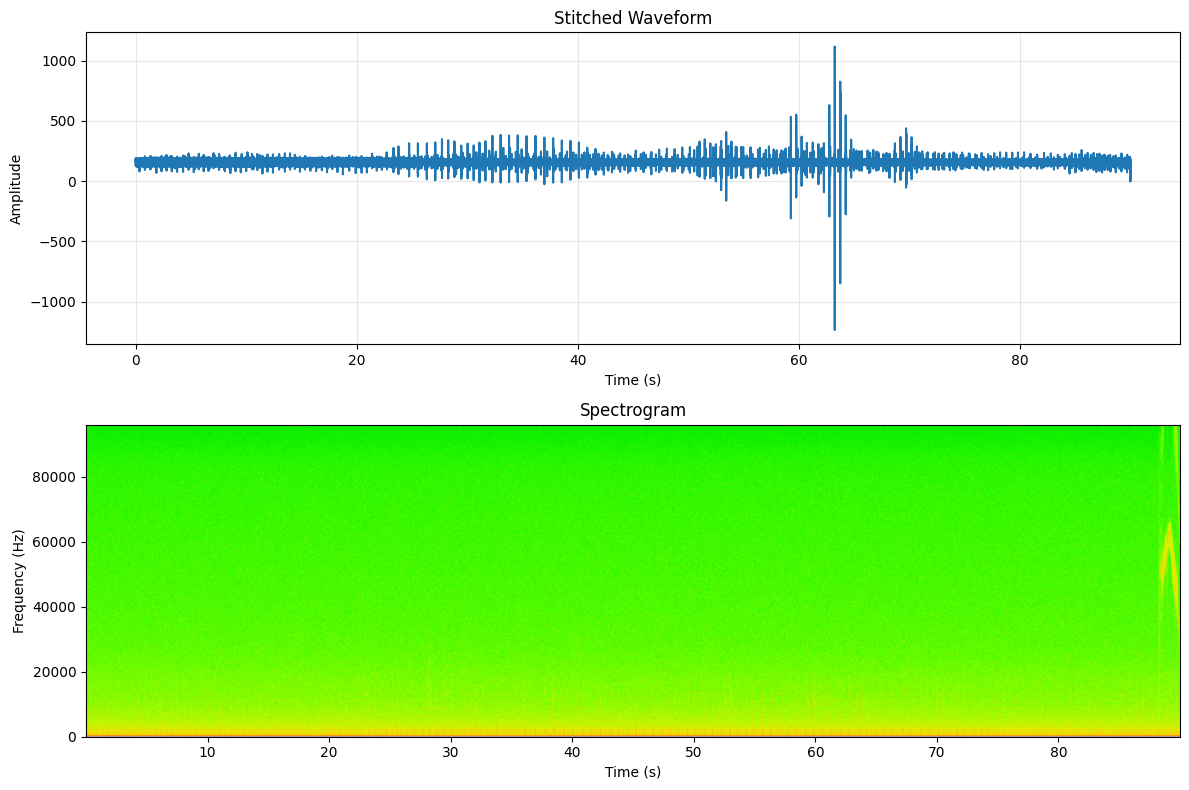

In [14]:
if 'audio_data' in locals() and len(audio_data) > 0:
    plt.figure(figsize=(12, 8))

    # Waveform
    plt.subplot(2, 1, 1)
    plt.plot(np.linspace(0, duration, len(audio_data)), audio_data)
    plt.title("Stitched Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)

    # Spectrogram
    plt.subplot(2, 1, 2)
    plt.specgram(audio_data, Fs=192000, NFFT=1024, noverlap=512, cmap='nipy_spectral')
    plt.title("Spectrogram")
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")

    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

In [13]:
# Save audio as WAV file for playback
from scipy.io import wavfile
normalized = np.int16(audio_data / np.max(np.abs(audio_data)) * 32767 * 0.9)
wavfile.write('stitched_audio.wav', 192000, normalized)
print("✓ Saved to stitched_audio.wav")

✓ Saved to stitched_audio.wav


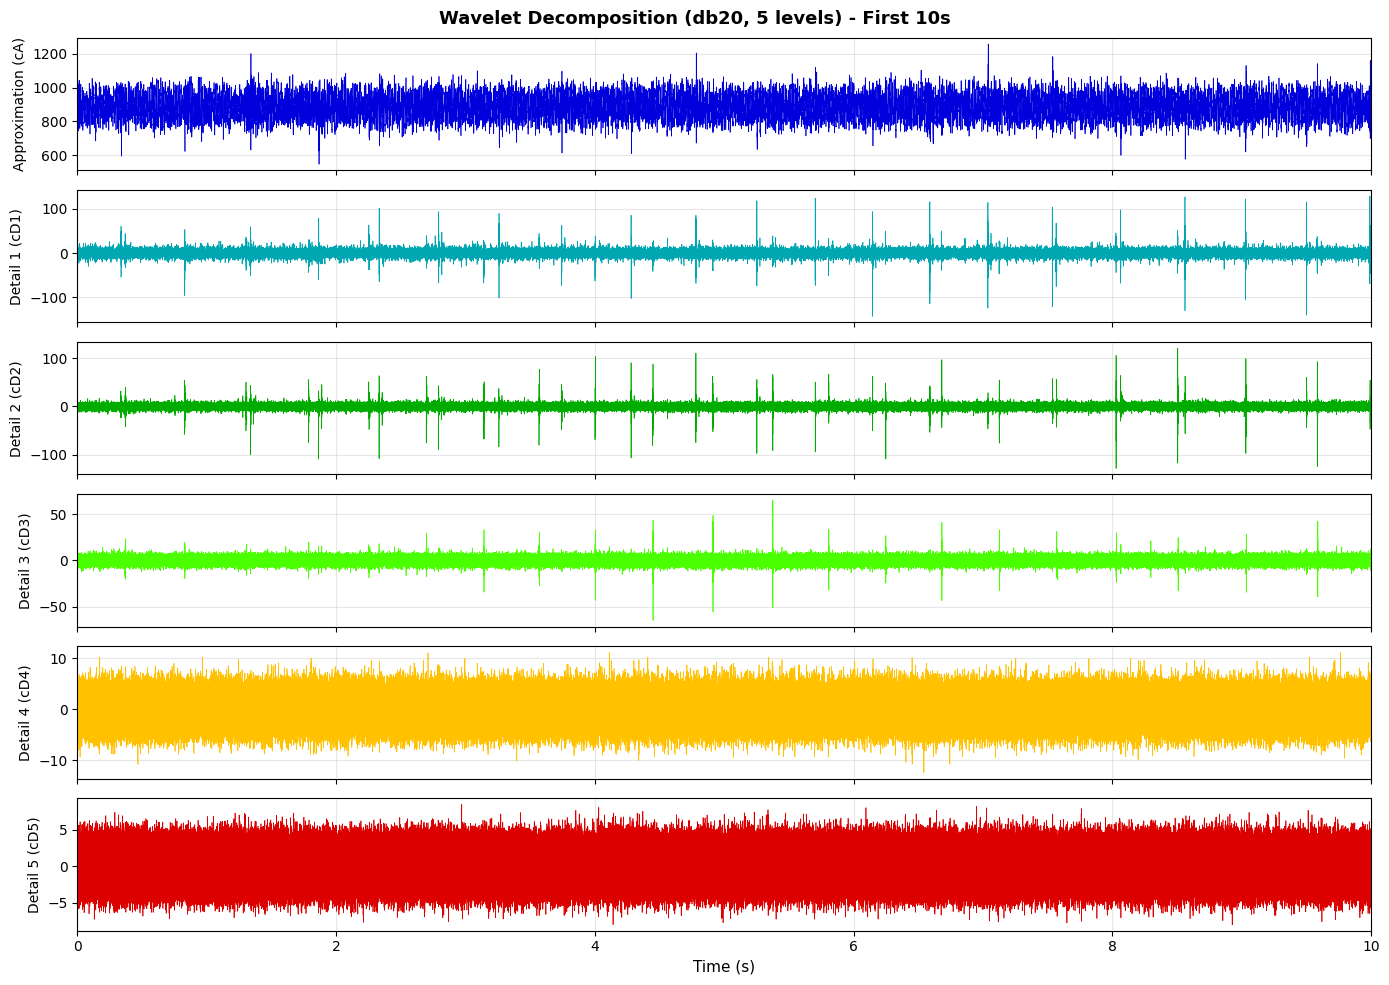

Decomposition levels: 6
Coefficient counts: [60037, 60037, 120036, 240034, 480029, 960019]


In [ ]:
# Wavelet decomposition visualization
import pywt

# Perform wavelet decomposition on a subset (first 10 seconds for clarity)

subset_duration = 10  # seconds
subset_samples = int(subset_duration * 192000)
data_subset = audio_data[:subset_samples]

# Decompose using db20 wavelet (same as used in denoising)
wavelet = 'db20'
coeffs = pywt.wavedec(data_subset, wavelet, level=5)

# Create stacked plot
fig, axes = plt.subplots(len(coeffs), 1, figsize=(14, 10), sharex=True)
time_subset = np.linspace(0, subset_duration, len(data_subset))

# Plot each level
level_names = ['Approximation (cA)'] + [f'Detail {i} (cD{i})' for i in range(1, len(coeffs))]
colors = plt.cm.nipy_spectral(np.linspace(0.2, 0.9, len(coeffs)))

for i, (coeff, name, color) in enumerate(zip(coeffs, level_names, colors)):
    # Create time array for this level
    t = np.linspace(0, subset_duration, len(coeff))
    axes[i].plot(t, coeff, linewidth=0.5, color=color)
    axes[i].set_ylabel(name, fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(0, subset_duration)

axes[-1].set_xlabel('Time (s)', fontsize=11)
fig.suptitle(f'Wavelet Decomposition ({wavelet}, 5 levels) - First {subset_duration}s', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Decomposition levels: {len(coeffs)}")
print(f"Coefficient counts: {[len(c) for c in coeffs]}")

## Summary

This notebook demonstrates:

1. **Built-in Catalog**: No need to build a catalog - Dolphain includes 1000 sample files by default
2. **Time-Based Access**: Request data by time range, not file names
3. **Automatic Stitching**: `getData()` seamlessly combines data across multiple files
4. **Continuous Audio**: The waveform and spectrogram above show continuous audio without gaps

**Key Functions:**
- `Catalog()` - Loads the built-in catalog (1000 files, ~6 hours)
- `getData(source, start_time, length_seconds)` - Fetches and stitches data from HuggingFace